# Q4: Eco-Friendly Intelligent Agents (low CO₂ and low water use)

## 0. Setup and the eco-footprint model

In [1]:
import math, heapq, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

GRID_CO2_G_PER_KWH   = 450
WATER_L_PER_KWH      = 1.9
VAN_CO2_G_PER_KM     = 270
CAR_CO2_G_PER_KM     = 170
VAN_WATER_L_PER_KM   = 0.6
CAR_WATER_L_PER_KM   = 0.4

def electricity_footprint(kwh):
    return kwh * GRID_CO2_G_PER_KWH, kwh * WATER_L_PER_KWH

ECO = {}
print("Setup done.")

Setup done.


---
# Part A: Simple Reflex Agent for abnormal movement in a crowd

| | |
|---|---|
| **Performance measure** | Detect running / counter-flow movement correctly (few misses, few false alarms) **and** keep energy (→ CO₂, water) low |
| **Environment** | A crowd (e.g. a station concourse) that normally walks in one main direction at walking pace |
| **Actuators** | Raise an alert; wake the high-power verification camera |
| **Sensors** | A low-power sensor (thermal / low-res camera) giving each person's current **speed** and **heading** |

### Condition-action rules
1. IF speed > 3.0 m/s → **ALERT_RUNNING**
2. IF heading is more than 120° away from the crowd flow AND speed > 0.8 m/s → **ALERT_COUNTERFLOW**
3. ELSE → **NORMAL**

### Eco design
* **Conventional system (baseline):** high-resolution camera + GPU analysis streaming 24/7 ≈ **150 W**.
* **Eco reflex agent:** microcontroller-level rules on a low-power sensor ≈ **5 W** continuously, plus a **+45 W burst only while an alert is active**.

In [2]:
rng = np.random.default_rng(42)
N, T, DT = 80, 120, 1.0                    # people, time steps (seconds), step length
AREA = np.array([100.0, 40.0])             # 100 m x 40 m concourse (flow heading = 0 rad, i.e. +x)

pos        = rng.uniform([0, 0], AREA, size=(N, 2))
base_speed = rng.normal(1.3, 0.25, N).clip(0.7, 2.0)   # normal walking speed (m/s)
base_head  = rng.normal(0.0, 0.25, N)                  # normal heading is close to the flow

# Injected abnormal behaviour (ground truth)
running_ids, run_win     = [0, 1, 2, 3], (40, 80)            # people who run
counter_ids, counter_win = [4, 5, 6],    (30, 90)            # people walking against the flow
panic_ids,   panic_win   = list(range(10, 18)), (95, 115)    # sudden panic: fast, random direction

def reflex_agent(speed, heading_dev_deg):
    if speed > 3.0:
        return "ALERT_RUNNING"
    if heading_dev_deg > 120 and speed > 0.8:
        return "ALERT_COUNTERFLOW"
    return "NORMAL"

records, snapshots = [], {}
for t in range(T):
    for i in range(N):
        sp, hd, truth = base_speed[i], base_head[i], "NORMAL"
        if i in running_ids and run_win[0] <= t < run_win[1]:
            sp, truth = rng.uniform(4, 6), "ALERT_RUNNING"
        elif i in counter_ids and counter_win[0] <= t < counter_win[1]:
            hd, truth = np.pi + rng.normal(0, 0.2), "ALERT_COUNTERFLOW"
        elif i in panic_ids and panic_win[0] <= t < panic_win[1]:
            sp, hd, truth = rng.uniform(4, 6.5), rng.uniform(-np.pi, np.pi), "ALERT_RUNNING"

        pos[i] = (pos[i] + sp * np.array([np.cos(hd), np.sin(hd)]) * DT) % AREA   # move (wrap around)

        # Noisy low-power sensor reading = the PERCEPT
        m_speed = max(0.0, sp + rng.normal(0, 0.3))
        m_head  = hd + rng.normal(0, 0.3)
        dev_deg = abs(np.degrees(np.angle(np.exp(1j * m_head))))   # angle to flow direction

        action = reflex_agent(m_speed, dev_deg)
        records.append((t, i, truth, action))
    if t == 100:
        snapshots["pos"] = pos.copy()

df_a = pd.DataFrame(records, columns=["t", "person", "truth", "action"])
snap_actions = df_a[df_a.t == 100].sort_values("person").action.values
print("Simulated", len(df_a), "person-observations")
df_a.head()

Simulated 9600 person-observations


,t,person,truth,action
0,0,0,NORMAL,NORMAL
1,0,1,NORMAL,NORMAL
2,0,2,NORMAL,NORMAL
3,0,3,NORMAL,NORMAL
4,0,4,NORMAL,NORMAL


In [3]:
y_true = (df_a.truth  != "NORMAL").astype(int)
y_pred = (df_a.action != "NORMAL").astype(int)

print("Confusion matrix (rows = truth, cols = agent) [normal, abnormal]:")
print(confusion_matrix(y_true, y_pred))
print()
print(classification_report(y_true, y_pred, target_names=["normal", "abnormal"], digits=3))
type_acc = (df_a.truth == df_a.action)[y_true == 1].mean()
print(f"Of the truly abnormal observations, the agent named the correct TYPE of anomaly {type_acc:.1%} of the time.")

Confusion matrix (rows = truth, cols = agent) [normal, abnormal]:
[[9100    0]
 [  18  482]]

              precision    recall  f1-score   support

      normal      0.998     1.000     0.999      9100
    abnormal      1.000     0.964     0.982       500

    accuracy                          0.998      9600
   macro avg      0.999     0.982     0.990      9600
weighted avg      0.998     0.998     0.998      9600

Of the truly abnormal observations, the agent named the correct TYPE of anomaly 96.4% of the time.


In [4]:
# ----------------------------- Energy -> CO2 and water -----------------------------
BASE_W, ECO_IDLE_W, ECO_BURST_W = 150.0, 5.0, 45.0

alert_active = df_a.groupby("t").action.apply(lambda s: (s != "NORMAL").any())   # any alert at step t?
duty_sim = alert_active.mean()

eco_avg_w_sim     = ECO_IDLE_W + ECO_BURST_W * duty_sim      # stress-test day: anomalies very frequent
TYPICAL_DUTY      = 0.02                                     # assumption: alerts active ~2 % of a normal day
eco_avg_w_typical = ECO_IDLE_W + ECO_BURST_W * TYPICAL_DUTY

def daily_footprint(avg_watts):
    kwh = avg_watts * 24 / 1000
    co2, water = electricity_footprint(kwh)
    return kwh, co2, water

rows = []
for label, w in [("Conventional 24/7 camera + GPU", BASE_W),
                 ("Eco reflex agent (this simulation, many anomalies)", eco_avg_w_sim),
                 ("Eco reflex agent (typical day, 2% alert duty)", eco_avg_w_typical)]:
    kwh, co2, water = daily_footprint(w)
    rows.append([label, round(w, 1), round(kwh, 3), round(co2, 1), round(water, 2)])
energy_a = pd.DataFrame(rows, columns=["System", "Avg power (W)", "kWh/day", "CO2 g/day", "Water L/day"])
print(f"Alert duty cycle in this (anomaly-heavy) simulation: {duty_sim:.0%}\n")
print(energy_a.to_string(index=False))

b = daily_footprint(BASE_W); e = daily_footprint(eco_avg_w_typical)
ECO["A"] = dict(unit="per day", base_co2=b[1], eco_co2=e[1], base_water=b[2], eco_water=e[2])
print(f"\nTypical-day saving: CO2 {1 - e[1]/b[1]:.0%}, water {1 - e[2]/b[2]:.0%}")

Alert duty cycle in this (anomaly-heavy) simulation: 67%

                                            System  Avg power (W)  kWh/day  CO2 g/day  Water L/day
                    Conventional 24/7 camera + GPU          150.0    3.600     1620.0         6.84
Eco reflex agent (this simulation, many anomalies)           35.0    0.840      378.0         1.60
     Eco reflex agent (typical day, 2% alert duty)            5.9    0.142       63.7         0.27

Typical-day saving: CO2 96%, water 96%


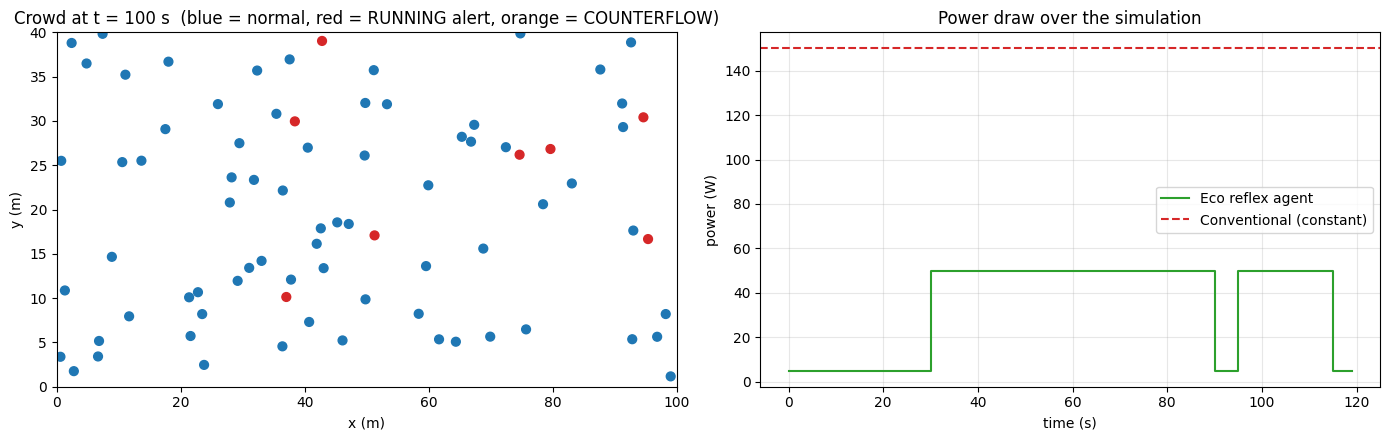

In [5]:
# ----------------------------- Visuals -----------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
p = snapshots["pos"]
col = np.where(snap_actions == "NORMAL", "tab:blue", np.where(snap_actions == "ALERT_RUNNING", "tab:red", "tab:orange"))
ax[0].scatter(p[:, 0], p[:, 1], c=col, s=40)
ax[0].set_title("Crowd at t = 100 s  (blue = normal, red = RUNNING alert, orange = COUNTERFLOW)")
ax[0].set_xlim(0, 100); ax[0].set_ylim(0, 40); ax[0].set_xlabel("x (m)"); ax[0].set_ylabel("y (m)")

power_eco = ECO_IDLE_W + ECO_BURST_W * alert_active.astype(float)
ax[1].step(range(T), power_eco, where="post", label="Eco reflex agent", color="tab:green")
ax[1].axhline(BASE_W, color="tab:red", ls="--", label="Conventional (constant)")
ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("power (W)"); ax[1].set_title("Power draw over the simulation")
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

**Interpretation (Part A):** The reflex rules catch running and counter-flow movement using only each person's *current* speed and heading, so the whole decision is a couple of comparisons. The agent is cheap precisely because it keeps no memory and builds no model. **Limitations** of a simple reflex agent: it cannot detect anomalies that need history (e.g. someone who suddenly stops, or loitering), and noisy percepts can cause missed detections or false alarms. The eco gain comes from keeping the expensive hardware asleep until a rule fires. The 96% saving is measured against an always-on 150 W system, so it depends on that baseline.

---
# Part B: Utility-based Agent for stressed and tense patients

| | |
|---|---|
| **Performance measure** | Reduce the patient's stress and raise comfort, while minimising CO₂, water and staff burden |
| **Environment** | A hospital ward / waiting area with patients of different stress levels and personal constraints |
| **Actuators** | Dim lights, calming music, guided-breathing audio, aromatherapy diffuser, herbal tea, nurse conversation, HVAC cooling, warm bath, escalate to clinician |
| **Sensors** | Stress score (0 to 10, from e.g. heart-rate variability / skin conductance), plus patient flags: noise-sensitive, scent-allergic, limited mobility |


In [6]:
# needs = constraint tag:  noise -> blocked if noise-sensitive | scent -> blocked if scent-allergic
#                           mobility -> blocked if limited mobility | severe -> only if stress >= 8
actions = pd.DataFrame([
    # action,                        p,    d_stress, comfort, CO2 g, water L, other_cost, needs
    ("Dim lights / natural light",   0.80, 1.0, 0.5,   5, 0.0, 0.0, ""),
    ("Calming music (low volume)",   0.70, 1.5, 1.0,   8, 0.0, 0.0, "noise"),
    ("Guided breathing audio",       0.75, 2.0, 0.5,   4, 0.0, 0.0, ""),
    ("Aromatherapy diffuser",        0.60, 1.2, 1.0,  12, 0.3, 0.0, "scent"),
    ("Herbal tea",                   0.70, 1.0, 1.5,  20, 0.4, 0.0, ""),
    ("Nurse conversation",           0.85, 3.0, 2.0,  10, 0.0, 2.0, ""),      # other_cost = staff time
    ("Lower room temperature (HVAC)",0.50, 0.8, 1.0, 400, 0.0, 0.0, ""),
    ("Warm bath / shower",           0.80, 2.0, 2.0, 600, 40.0, 0.0, "mobility"),
    ("Escalate to clinician",        0.90, 4.5, 0.0,   8, 0.0, 1.5, "severe"), # other_cost = clinical burden
], columns=["action", "p_success", "d_stress", "comfort", "co2_g", "water_L", "other_cost", "needs"]).set_index("action")

# Utility weights (the eco-weights are what makes the agent "eco-friendly")
W = dict(stress=1.0, comfort=0.4, co2=0.004, water=0.04)   # 400 g CO2 costs 1.6 utility; 40 L water costs 1.6

def net_utility(row, w=W):
    return (w["stress"] * row.p_success * row.d_stress + w["comfort"] * row.comfort
            - w["co2"] * row.co2_g - w["water"] * row.water_L - row.other_cost)

def feasible(row, patient):
    n = row.needs
    return not ((n == "noise" and patient["noise_sensitive"]) or (n == "scent" and patient["scent_allergy"])
                or (n == "mobility" and patient["limited_mobility"]) or (n == "severe" and patient["stress"] < 8))

def plan(patient, w=W, target=3.0, max_actions=4):
    stress, chosen = patient["stress"], []
    pool = [a for a, r in actions.iterrows() if feasible(r, patient)]
    while stress > target and pool and len(chosen) < max_actions:
        best = max(pool, key=lambda a: net_utility(actions.loc[a], w))
        if net_utility(actions.loc[best], w) <= 0:
            break                                      # nothing left that is worth its cost
        chosen.append(best); pool.remove(best)
        stress -= actions.loc[best].p_success * actions.loc[best].d_stress
    return chosen, max(stress, 0.0)

actions["net_utility"] = [net_utility(r) for _, r in actions.iterrows()]
actions[["p_success", "d_stress", "comfort", "co2_g", "water_L", "other_cost", "net_utility"]].round(2)

,p_success,d_stress,comfort,co2_g,water_L,other_cost,net_utility
action,,,,,,,
Dim lights / natural light,0.80,1.0,0.5,5,0.0,0.0,0.98
Calming music (low volume),0.70,1.5,1.0,8,0.0,0.0,1.42
Guided breathing audio,0.75,2.0,0.5,4,0.0,0.0,1.68
Aromatherapy diffuser,0.60,1.2,1.0,12,0.3,0.0,1.06
Herbal tea,0.70,1.0,1.5,20,0.4,0.0,1.20
Nurse conversation,0.85,3.0,2.0,10,0.0,2.0,1.31
Lower room temperature (HVAC),0.50,0.8,1.0,400,0.0,0.0,-0.80
Warm bath / shower,0.80,2.0,2.0,600,40.0,0.0,-1.60
Escalate to clinician,0.90,4.5,0.0,8,0.0,1.5,2.52


In [7]:
# ----------------------------- Patients and decisions -----------------------------
def P(name, stress, noise=False, scent=False, mob=False):
    return dict(name=name, stress=stress, noise_sensitive=noise, scent_allergy=scent, limited_mobility=mob)

patients = [P("P1 mild tension", 4.5),
            P("P2 moderate, noise-sensitive", 6.5, noise=True),
            P("P3 high, scent allergy", 8.5, scent=True),
            P("P4 severe anxiety", 9.5),
            P("P5 moderate, limited mobility", 6.0, mob=True)]

# Conventional fixed protocol for ANY stressed patient: cool the room + warm bath + nurse
BASELINE_PROTOCOL = ["Lower room temperature (HVAC)", "Warm bath / shower", "Nurse conversation"]
base_co2   = actions.loc[BASELINE_PROTOCOL, "co2_g"].sum()
base_water = actions.loc[BASELINE_PROTOCOL, "water_L"].sum()

rows = []
for pt in patients:
    chosen, after = plan(pt)
    rows.append([pt["name"], pt["stress"], " + ".join(chosen), round(after, 2),
                 actions.loc[chosen, "co2_g"].sum(), round(actions.loc[chosen, "water_L"].sum(), 1),
                 base_co2, base_water])
res_b = pd.DataFrame(rows, columns=["Patient", "Stress now", "Agent's chosen actions", "Expected stress after",
                                    "Agent CO2 g", "Agent water L", "Baseline CO2 g", "Baseline water L"])
res_b

,Patient,Stress now,Agent's chosen actions,Expected stress after,Agent CO2 g,Agent water L,Baseline CO2 g,Baseline water L
0,P1 mild tension,4.5,Guided breathing audio,3.00,4,0.0,1010,40.0
1,"P2 moderate, noise-sensitive",6.5,Guided breathing audio + Nurse conversation,2.45,14,0.0,1010,40.0
2,"P3 high, scent allergy",8.5,Escalate to clinician + Guided breathing audio,2.95,12,0.0,1010,40.0
3,P4 severe anxiety,9.5,Escalate to clinician + Guided breathing audio...,2.90,20,0.0,1010,40.0
4,"P5 moderate, limited mobility",6.0,Guided breathing audio + Calming music (low vo...,0.90,22,0.0,1010,40.0


Average per patient: agent CO2 = 14.4 g, baseline CO2 = 1010 g
Average per patient: agent water = 0.00 L, baseline water = 40 L


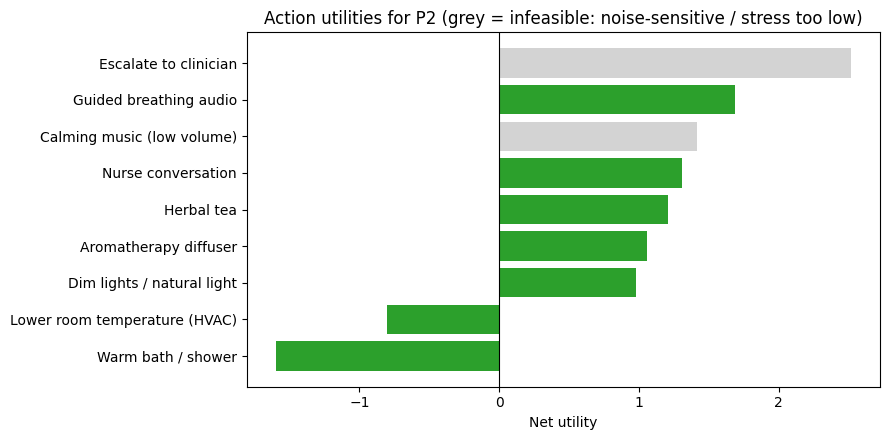

In [8]:
print(f"Average per patient: agent CO2 = {res_b['Agent CO2 g'].mean():.1f} g, baseline CO2 = {base_co2:.0f} g")
print(f"Average per patient: agent water = {res_b['Agent water L'].mean():.2f} L, baseline water = {base_water:.0f} L")
ECO["B"] = dict(unit="per patient", base_co2=base_co2, eco_co2=res_b["Agent CO2 g"].mean(),
                base_water=base_water, eco_water=res_b["Agent water L"].mean())

# Utility of every action for the noise-sensitive patient (feasible ones highlighted)
pt = patients[1]
fe = {a: feasible(r, pt) for a, r in actions.iterrows()}
s = actions["net_utility"].sort_values()
plt.figure(figsize=(9, 4.5))
plt.barh(s.index, s.values, color=["tab:green" if fe[a] else "lightgray" for a in s.index])
plt.axvline(0, color="k", lw=.8); plt.xlabel("Net utility")
plt.title("Action utilities for P2 (grey = infeasible: noise-sensitive / stress too low)")
plt.tight_layout(); plt.show()

In [9]:
# ----------------------------- Sensitivity: how much does the eco-weight matter? -----------------------------
pt = patients[3]   # severe anxiety
rows = []
for m in [0, 0.25, 1, 2, 4]:
    w = dict(W); w["co2"] *= m; w["water"] *= m
    chosen, after = plan(pt, w)
    rows.append([m, " + ".join(chosen), round(after, 2), actions.loc[chosen, "co2_g"].sum(),
                 round(actions.loc[chosen, "water_L"].sum(), 1)])
pd.DataFrame(rows, columns=["Eco-weight multiplier", "Chosen actions", "Expected stress after", "CO2 g", "Water L"])

,Eco-weight multiplier,Chosen actions,Expected stress after,CO2 g,Water L
0,0.00,Escalate to clinician + Warm bath / shower + G...,2.35,612,40.0
1,0.25,Escalate to clinician + Guided breathing audio...,2.90,20,0.0
2,1.00,Escalate to clinician + Guided breathing audio...,2.90,20,0.0
3,2.00,Escalate to clinician + Guided breathing audio...,2.90,20,0.0
4,4.00,Escalate to clinician + Guided breathing audio...,2.90,20,0.0


**Interpretation (Part B):** The utility-based agent calms every patient using mainly low-footprint actions (breathing audio, music, lighting, a nurse) and avoids high-footprint ones (HVAC cooling and the warm bath) because their utility is negative once CO₂ and water are priced in. It also respects patient-specific limits (no music for noise-sensitive patients, no scents for allergic ones, no bath for limited mobility) and only escalates to a clinician when stress is severe. The sensitivity table shows the *trade-off*: with the eco-weight set to 0 the agent is willing to use the warm bath (about 612 g CO₂ and 40 L water for that patient), while even a quarter of the default eco-weight is enough to make it choose low-footprint actions instead. Two caveats: (1) the baseline is a deliberately resource-heavy fixed protocol applied to everyone, so the saving is large by construction; (2) the greedy planner can overshoot the stress target slightly (e.g. P5 ends well below 3.0) because it adds whole actions.

---
# Part C: Goal-based Agent for the school-van network 

| | |
|---|---|
| **Performance measure** | Every child picked up and delivered to school, with **low risk** and **low distance (CO₂, water)** and an acceptable ride time |
| **Environment** | A road network with pickup stops, vans (capacity limited), and roads of differing safety |
| **Actuators** | Assign stops to vans; drive along chosen roads |
| **Sensors** | Road map (distances), road-risk scores, number of children at each stop |


* **State** = (current location, set of stops already visited)
* **Actions** = drive to an unvisited stop, or to the school at the end
* **Step cost** = shortest *safe-road* distance, where each road's cost = length × (1 + λ·risk)
* **Safety constraint:** roads with risk above a limit are **forbidden** ("secure commute")
* **Goal test** = all assigned stops visited and the van is at school
* **Capacity constraint:** each van carries at most 14 children, so the agent also searches over how to **split stops between the 2 vans**.

In [10]:
# ----------------------------- Road network -----------------------------
nodes = {"School": (0, 0), "Depot": (2.5, -3.5), "A": (-2, 2), "B": (-3, 0.5), "C": (-1.5, -2),
         "D": (2, 2.5), "E": (3.5, 1), "F": (2, -1.5), "G": (4, -2.5), "H": (0.5, 3.5)}
children = {"A": 3, "B": 4, "C": 2, "D": 5, "E": 3, "F": 4, "G": 2, "H": 3}     # children per pickup stop
stops = list(children)
CAP, SPEED_KMH, STOP_MIN = 14, 25, 1.0
RISK_MAX, LAMBDA = 0.6, 2.0

def euclid(a, b): return float(np.hypot(*(np.array(nodes[a]) - np.array(nodes[b]))))

# Roads: connect each place to its 3 nearest neighbours (road length = 1.25 x straight line)
edges = {}
for a in nodes:
    for d, b in sorted([(euclid(a, b), b) for b in nodes if b != a])[:3]:
        edges[tuple(sorted((a, b)))] = round(d * 1.25, 2)

rg = np.random.default_rng(3)
risk = {k: round(float(rg.uniform(0.05, 0.35)), 2) for k in edges}
risk[("D", "School")] = 0.90        # busy highway crossing
risk[("F", "School")] = 0.85        # road beside a market / many accidents

print(f"{len(edges)} roads, {len(stops)} stops, {sum(children.values())} children, van capacity {CAP}")
print("High-risk roads (forbidden by the safety rule):", [k for k, v in risk.items() if v > RISK_MAX])

18 roads, 8 stops, 26 children, van capacity 14
High-risk roads (forbidden by the safety rule): [('F', 'School'), ('D', 'School')]


In [11]:
# ----------------------------- Shortest paths (Dijkstra) -----------------------------
def build_paths(use_risk):
    adj = {n: [] for n in nodes}
    for (a, b), L in edges.items():
        if use_risk and risk[(a, b)] > RISK_MAX:
            continue
        cost = L * (1 + LAMBDA * risk[(a, b)]) if use_risk else L
        adj[a].append((b, cost)); adj[b].append((a, cost))
    cost_tab, path_tab = {}, {}
    for s in nodes:
        dist, prev, pq = {s: 0.0}, {}, [(0.0, s)]
        while pq:
            d, u = heapq.heappop(pq)
            if d > dist.get(u, 1e18): continue
            for v, c in adj[u]:
                if d + c < dist.get(v, 1e18):
                    dist[v], prev[v] = d + c, u
                    heapq.heappush(pq, (d + c, v))
        for t in nodes:
            if t in dist:
                p, cur = [t], t
                while cur != s: cur = prev[cur]; p.append(cur)
                cost_tab[(s, t)], path_tab[(s, t)] = dist[t], p[::-1]
    return cost_tab, path_tab

SAFE_COST, SAFE_PATH = build_paths(use_risk=True)    # eco / secure agent
FAST_COST, FAST_PATH = build_paths(use_risk=False)   # naive: shortest distance, ignores risk
assert all((a, b) in SAFE_COST for a in nodes for b in nodes), "Safe network is not connected!"
print("Safe network is fully connected: every stop can reach the school without a risky road.")

Safe network is fully connected: every stop can reach the school without a risky road.


In [12]:
# ----------------------------- GOAL-BASED AGENT: uniform-cost search -----------------------------
def best_route(stop_subset, cost_tab):
    """Uniform-cost search from the Depot to the goal (all stops visited and at School)."""
    stop_subset = tuple(sorted(stop_subset))
    if not stop_subset:
        return 0.0, []
    start = ("Depot", frozenset())
    pq, best = [(0.0, "Depot", frozenset(), [])], {start: 0.0}
    while pq:
        g, loc, visited, order = heapq.heappop(pq)
        if loc == "School" and visited == frozenset(stop_subset):        # GOAL TEST
            return g, order
        if g > best.get((loc, visited), 1e18):
            continue
        remaining = [s for s in stop_subset if s not in visited]
        succ = remaining if remaining else ["School"]
        for nxt in succ:                                              # ACTIONS
            c = g + cost_tab[(loc, nxt)]
            nv = visited | {nxt} if nxt != "School" else visited
            state = (nxt, nv)
            if c < best.get(state, 1e18):
                best[state] = c
                heapq.heappush(pq, (c, nxt, nv, order + ([nxt] if nxt != "School" else [])))
    return 1e18, []

route_memo = {}
def route_cost(subset, cost_tab, key):
    k = (key, tuple(sorted(subset)))
    if k not in route_memo:
        route_memo[k] = best_route(subset, cost_tab)
    return route_memo[k]

# Search over how to split the stops between 2 vans (capacity constraint), minimising total cost
best_plan = (1e18, None)
for r in range(len(stops) + 1):
    for sub in itertools.combinations(stops, r):
        rest = [s for s in stops if s not in sub]
        if sum(children[s] for s in sub) > CAP or sum(children[s] for s in rest) > CAP:
            continue
        total = route_cost(sub, SAFE_COST, "safe")[0] + route_cost(rest, SAFE_COST, "safe")[0]
        if total < best_plan[0]:
            best_plan = (total, (sub, rest))

(vanA, vanB) = best_plan[1]
eco_routes = [route_cost(vanA, SAFE_COST, "safe")[1], route_cost(vanB, SAFE_COST, "safe")[1]]
print("Goal-based agent plan:")
for i, r in enumerate(eco_routes, 1):
    print(f"  Van {i}: Depot -> " + " -> ".join(r) + f" -> School   (children: {sum(children[s] for s in r)})")

Goal-based agent plan:
  Van 1: Depot -> F -> C -> B -> A -> School   (children: 13)
  Van 2: Depot -> G -> E -> D -> H -> School   (children: 13)


In [13]:
# ----------------------------- Evaluate any plan (distance, risk, time, CO2, water) -----------------------------
def expand(route, path_tab):
    """Full node-by-node path for a route Depot -> stops -> School."""
    seq, full = ["Depot"] + list(route) + ["School"], []
    for a, b in zip(seq[:-1], seq[1:]):
        seg = path_tab[(a, b)]
        full += seg if not full else seg[1:]
    return full

def evaluate(routes, path_tab, per_km_co2, per_km_water):
    km = exposure = 0.0
    for r in routes:
        full = expand(r, path_tab)
        for a, b in zip(full[:-1], full[1:]):
            key = tuple(sorted((a, b)))
            km += edges[key]; exposure += edges[key] * risk[key]
    ride_min = [sum(edges[tuple(sorted(p))] for p in zip(expand(r, path_tab)[:-1], expand(r, path_tab)[1:])) / SPEED_KMH * 60
                + STOP_MIN * len(r) for r in routes]
    return dict(km=km, risk_exposure=exposure, max_trip_min=max(ride_min), co2_g=km * per_km_co2, water_L=km * per_km_water)

# Baseline 1: every child travels by private car (direct to school, shortest road)
car_km = sum(children[s] * sum(edges[tuple(sorted(p))] for p in zip(FAST_PATH[(s, "School")][:-1], FAST_PATH[(s, "School")][1:]))
             for s in stops)
car = dict(km=car_km, risk_exposure=float("nan"), max_trip_min=float("nan"),
           co2_g=car_km * CAR_CO2_G_PER_KM, water_L=car_km * CAR_WATER_L_PER_KM)

# Baseline 2: naive vans - stops split in list order, visited in list order, shortest roads (ignores risk)
naive_routes, load, cur = [], 0, []
for s in stops:
    if load + children[s] > CAP: naive_routes.append(cur); cur, load = [], 0
    cur.append(s); load += children[s]
naive_routes.append(cur)
naive = evaluate(naive_routes, FAST_PATH, VAN_CO2_G_PER_KM, VAN_WATER_L_PER_KM)

# The goal-based agent
eco = evaluate(eco_routes, SAFE_PATH, VAN_CO2_G_PER_KM, VAN_WATER_L_PER_KM)

cmp_c = pd.DataFrame({"26 private cars": car, "Naive vans (ignore risk)": naive, "Goal-based eco vans": eco}).T
cmp_c = cmp_c[["km", "risk_exposure", "max_trip_min", "co2_g", "water_L"]].round(2)
cmp_c.columns = ["Total km", "Risk exposure (risk x km)", "Longest trip (min)", "CO2 g", "Water L"]
cmp_c

,Total km,Risk exposure (risk x km),Longest trip (min),CO2 g,Water L
26 private cars,109.59,NaN,NaN,18630.3,43.84
Naive vans (ignore risk),52.65,18.82,67.36,14215.5,31.59
Goal-based eco vans,32.42,7.40,43.43,8753.4,19.45


Eco vans vs private cars: CO2 -53%, water -56%
Eco vans vs naive vans:  CO2 -38%, risk exposure -61%


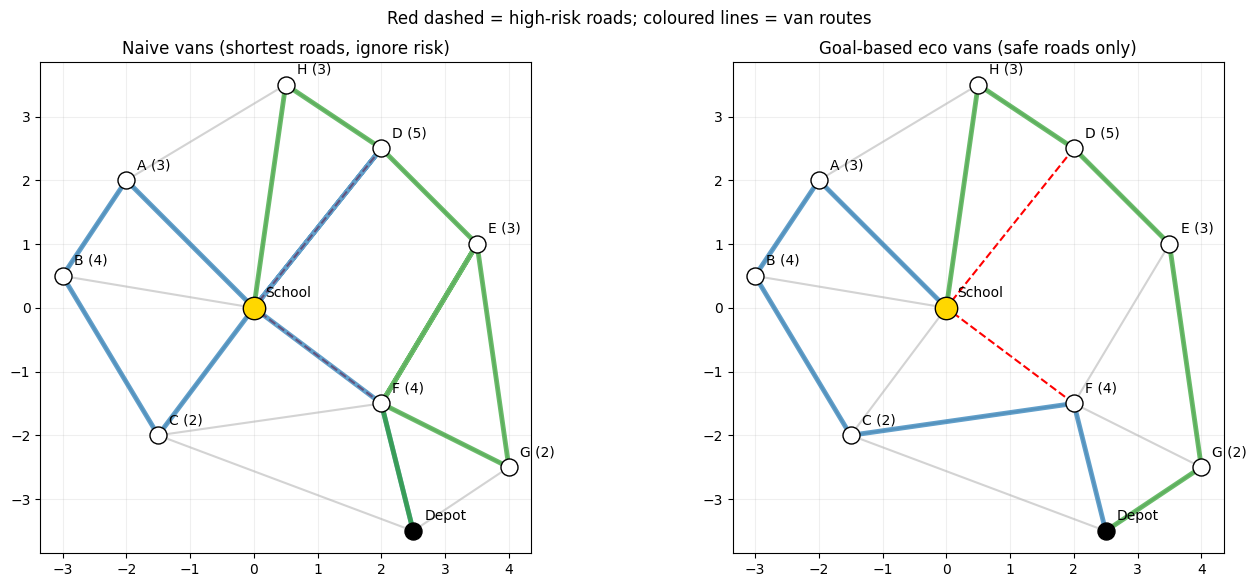

In [14]:
ECO["C"] = dict(unit="per morning", base_co2=car["co2_g"], eco_co2=eco["co2_g"], base_water=car["water_L"], eco_water=eco["water_L"])
print(f"Eco vans vs private cars: CO2 -{1 - eco['co2_g']/car['co2_g']:.0%}, water -{1 - eco['water_L']/car['water_L']:.0%}")
print(f"Eco vans vs naive vans:  CO2 {eco['co2_g']/naive['co2_g'] - 1:+.0%}, risk exposure {eco['risk_exposure']/naive['risk_exposure'] - 1:+.0%}")

# ----------------------------- Map -----------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
for ax, routes, ptab, title in [(axs[0], naive_routes, FAST_PATH, "Naive vans (shortest roads, ignore risk)"),
                                (axs[1], eco_routes, SAFE_PATH, "Goal-based eco vans (safe roads only)")]:
    for (a, b), L in edges.items():
        xa, ya = nodes[a]; xb, yb = nodes[b]
        ax.plot([xa, xb], [ya, yb], color="red" if risk[(a, b)] > RISK_MAX else "lightgray",
                ls="--" if risk[(a, b)] > RISK_MAX else "-", lw=1.5, zorder=1)
    for r, colr in zip(routes, ["tab:blue", "tab:green"]):
        full = expand(r, ptab)
        ax.plot([nodes[n][0] for n in full], [nodes[n][1] for n in full], color=colr, lw=3.5, alpha=.7, zorder=2)
    for n, (x, y) in nodes.items():
        ax.scatter(x, y, s=260 if n == "School" else 150, c="gold" if n == "School" else ("black" if n == "Depot" else "white"),
                   edgecolor="k", zorder=3)
        ax.annotate(n if n in ("School", "Depot") else f"{n} ({children[n]})", (x, y), textcoords="offset points", xytext=(8, 8), fontsize=10)
    ax.set_title(title); ax.set_aspect("equal"); ax.grid(alpha=.2)
plt.suptitle("Red dashed = high-risk roads; coloured lines = van routes", y=0.97)
plt.tight_layout(); plt.show()

**Interpretation (Part C):** The goal-based agent does not just react: it **searches** for a plan that satisfies the goal (all children dropped) under constraints (capacity, safe roads only). Because it considers both distance and risk, its vans never use the forbidden high-risk roads, and the table shows its routes are also much shorter than the naive vans' (it optimises which stops each van takes and in what order), with far lower risk exposure and a shorter longest trip. In general the safe-road rule can add distance; here the smarter assignment more than offsets it. Compared with every child travelling in a private car, sharing two vans roughly halves CO₂ and fuel-related water in this instance.

---
# Part D: Learning Agent to encourage sports among young people

| | |
|---|---|
| **Performance measure** | High *engagement* (young person actually does the activity) with a **low CO₂ and water footprint** per recommendation |
| **Environment** | Young people with different interests, in different weather |
| **Actuators** | Send a recommendation (an activity nudge) |
| **Sensors** | User profile (from onboarding: team-player, solo-fitness, casual, outdoor-adventurer), current weather, and feedback on whether the activity was done |

### Learning-agent architecture (maps to the textbook diagram)
| Component | In this notebook |
|---|---|
| **Performance element** | Chooses the activity to recommend from the current action-value table `Q` |
| **Critic** | Computes the reward: `engaged (0/1) − λ × eco-cost` |
| **Learning element** | Updates `Q[context, activity]` with the incremental sample-average rule |
| **Problem generator** | ε-greedy exploration: occasionally tries a different activity to discover better ones |

This is a **contextual bandit** (one decision per episode, the context is *profile × weather*).

$$Q(c,a) \leftarrow Q(c,a) + \frac{1}{n(c,a)}\big(r - Q(c,a)\big), \qquad r = \text{engaged} - \lambda\Big(\tfrac{\text{CO}_2\,[g]}{1000} + \tfrac{\text{water}\,[L]}{100}\Big)$$

The agent does **not** know how likely each type of person is to accept each activity. It must learn it from feedback. We compare three policies: **random**, an **engagement-only learner** (λ = 0, ignores eco cost) and the **eco learner** (λ = 0.5).

In [15]:
# ----------------------------- Environment (hidden from the agent) -----------------------------
activities = pd.DataFrame([
    # activity,                co2_g, water_L, outdoor?, swim?
    ("Walk/cycle to school",       0,   0.0, True,  False),
    ("Street football/cricket",    5,   2.0, True,  False),
    ("Park jogging group",         0,   1.0, True,  False),
    ("Home workout video",        30,   0.5, False, False),
    ("Gym session",              700,  15.0, False, False),
    ("Swimming pool",            900,  60.0, False, True),
], columns=["activity", "co2_g", "water_L", "outdoor", "swim"]).set_index("activity")

profiles = ["Team-player", "Solo-fitness", "Casual/screen-lover", "Outdoor-adventurer"]
weathers = ["Mild", "Hot", "Rainy"]
BASE_P = pd.DataFrame([[0.45, 0.85, 0.50, 0.30, 0.55, 0.50],      # chance a person of this profile accepts each activity
                       [0.50, 0.30, 0.60, 0.60, 0.85, 0.70],
                       [0.35, 0.40, 0.25, 0.65, 0.30, 0.45],
                       [0.70, 0.65, 0.80, 0.25, 0.30, 0.60]],
                      index=profiles, columns=activities.index)

def true_p(profile, weather, activity):
    p = BASE_P.loc[profile, activity]
    a = activities.loc[activity]
    if a.swim:      p *= {"Mild": 1.0, "Hot": 1.25, "Rainy": 0.9}[weather]
    elif a.outdoor: p *= {"Mild": 1.0, "Hot": 0.7,  "Rainy": 0.35}[weather]
    else:           p *= {"Mild": 1.0, "Hot": 1.0,  "Rainy": 1.15}[weather]
    return min(p, 0.95)

contexts = [(p, w) for p in profiles for w in weathers] 
act_names = list(activities.index)

def eco_cost(activity):                                         # un-weighted eco cost of an activity
    a = activities.loc[activity]
    return a.co2_g / 1000 + a.water_L / 100

print("12 contexts x 6 activities. The agent starts knowing NOTHING about acceptance rates.")
activities.assign(eco_cost=[round(eco_cost(a), 3) for a in act_names])

12 contexts x 6 activities. The agent starts knowing NOTHING about acceptance rates.


,co2_g,water_L,outdoor,swim,eco_cost
activity,,,,,
Walk/cycle to school,0,0.0,True,False,0.000
Street football/cricket,5,2.0,True,False,0.025
Park jogging group,0,1.0,True,False,0.010
Home workout video,30,0.5,False,False,0.035
Gym session,700,15.0,False,False,0.850
Swimming pool,900,60.0,False,True,1.500


In [16]:
# ----------------------------- The learning agent -----------------------------
class LearningAgent:
    def __init__(self, lam, eps0=1.0, eps_min=0.05, decay=0.999, seed=0):
        self.lam, self.eps, self.eps_min, self.decay = lam, eps0, eps_min, decay
        self.Q = np.zeros((len(contexts), len(act_names)))
        self.n = np.zeros_like(self.Q)
        self.rng = np.random.default_rng(seed)

    def act(self, ci):                       # PERFORMANCE ELEMENT (+ PROBLEM GENERATOR via epsilon)
        if self.rng.random() < self.eps:
            return int(self.rng.integers(len(act_names)))     # explore
        return int(np.argmax(self.Q[ci]))                     # exploit

    def reward(self, engaged, ai):           # CRITIC
        return engaged - self.lam * eco_cost(act_names[ai])

    def learn(self, ci, ai, r):              # LEARNING ELEMENT
        self.n[ci, ai] += 1
        self.Q[ci, ai] += (r - self.Q[ci, ai]) / self.n[ci, ai]
        self.eps = max(self.eps_min, self.eps * self.decay)

def train(lam, episodes=6000, seed=0):
    env_rng = np.random.default_rng(100 + seed)
    ag = LearningAgent(lam, seed=seed)
    log = []
    for _ in range(episodes):
        ci = int(env_rng.integers(len(contexts)))             # a young person appears
        prof, wea = contexts[ci]
        ai = ag.act(ci)                                        # agent recommends an activity
        engaged = float(env_rng.random() < true_p(prof, wea, act_names[ai]))   # feedback from the world
        r = ag.reward(engaged, ai)
        ag.learn(ci, ai, r)
        log.append((ci, ai, engaged))
    return ag, log

LAM_ECO = 0.5
agent_eco,  log_eco  = train(LAM_ECO)
agent_eng,  log_eng  = train(0.0)
print("Training finished (6000 simulated young people for each learner).")

Training finished (6000 simulated young people for each learner).


In [17]:
# ----------------------------- What did the eco learner learn? -----------------------------
def policy_of(agent): return [int(np.argmax(agent.Q[ci])) for ci in range(len(contexts))]

# The truly optimal choice under the eco reward (computed from the hidden true probabilities)
def optimal_policy(lam):
    return [int(np.argmax([true_p(p, w, a) - lam * eco_cost(a) for a in act_names])) for (p, w) in contexts]

pol_eco, pol_eng, pol_opt = policy_of(agent_eco), policy_of(agent_eng), optimal_policy(LAM_ECO)

learned = pd.DataFrame([[act_names[pol_eco[i * 3 + j]] for j in range(3)] for i in range(4)], index=profiles, columns=weathers)
print("Activity recommended by the ECO learner for each (profile, weather):")
print(learned)
print(f"\nMatches the true optimum in {np.mean(np.array(pol_eco) == np.array(pol_opt)):.0%} of the 12 contexts.")

Activity recommended by the ECO learner for each (profile, weather):
                                        Mild                      Hot                 Rainy
Team-player          Street football/cricket  Street football/cricket    Home workout video
Solo-fitness              Home workout video       Home workout video    Home workout video
Casual/screen-lover       Home workout video       Home workout video    Home workout video
Outdoor-adventurer        Park jogging group     Walk/cycle to school  Walk/cycle to school

Matches the true optimum in 75% of the 12 contexts.


In [18]:
# ----------------------------- Evaluate policies with the TRUE probabilities -----------------------------
def evaluate_policy(policy):
    eng = np.mean([true_p(*contexts[ci], act_names[ai]) for ci, ai in enumerate(policy)])
    co2 = np.mean([activities.loc[act_names[ai], "co2_g"]   for ai in policy])
    wat = np.mean([activities.loc[act_names[ai], "water_L"] for ai in policy])
    return eng, co2, wat

rand_eng = np.mean([[true_p(*c, a) for a in act_names] for c in contexts])
rand_co2, rand_wat = activities.co2_g.mean(), activities.water_L.mean()

res_d = pd.DataFrame({
    "Random recommendations": (rand_eng, rand_co2, rand_wat),
    "Learner, engagement-only (lambda=0)": evaluate_policy(pol_eng),
    "Eco learner (lambda=0.5)": evaluate_policy(pol_eco),
}, index=["Expected engagement", "CO2 g per recommendation", "Water L per recommendation"]).T.round(3)
print(res_d)

e_eng, e_eco = evaluate_policy(pol_eng), evaluate_policy(pol_eco)
ECO["D"] = dict(unit="per recommendation", base_co2=e_eng[1], eco_co2=e_eco[1], base_water=e_eng[2], eco_water=e_eco[2])

                                     Expected engagement  CO2 g per recommendation  Water L per recommendation
Random recommendations                             0.445                   272.500                      13.083
Learner, engagement-only (lambda=0)                0.731                   464.167                      20.500
Eco learner (lambda=0.5)                           0.605                    18.333                       0.708


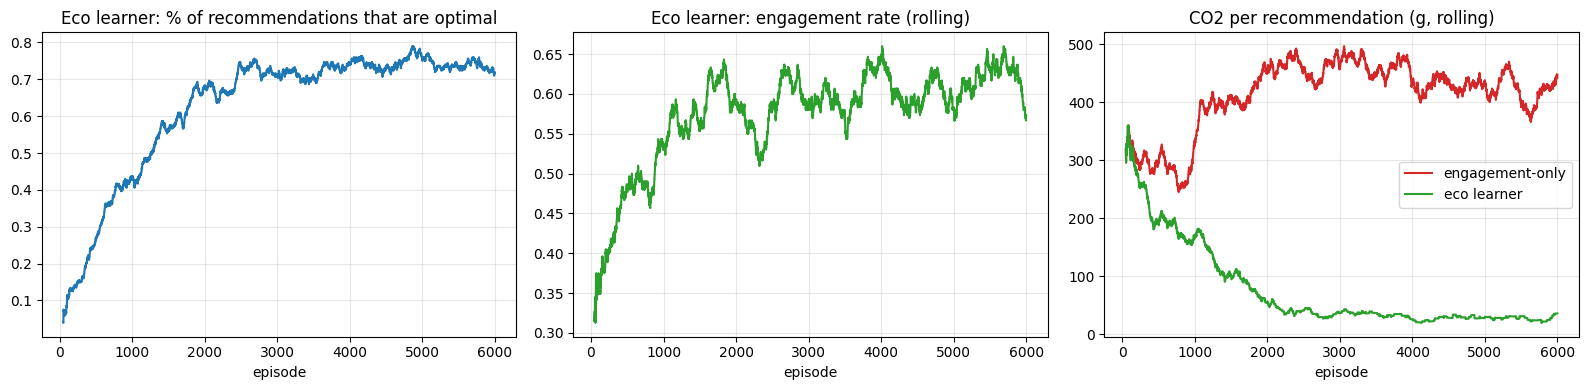

In [19]:
# ----------------------------- Learning curves -----------------------------
def rolling(x, w=300): return pd.Series(x).rolling(w, min_periods=50).mean()

opt_actions = np.array(pol_opt)
hit_eco = [int(ai == opt_actions[ci]) for ci, ai, _ in log_eco]
eng_eco = [e for _, _, e in log_eco]
co2_eco = [activities.loc[act_names[ai], "co2_g"]   for _, ai, _ in log_eco]
co2_eng = [activities.loc[act_names[ai], "co2_g"]   for _, ai, _ in log_eng]

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(rolling(hit_eco)); ax[0].set_title("Eco learner: % of recommendations that are optimal"); ax[0].set_xlabel("episode"); ax[0].grid(alpha=.3)
ax[1].plot(rolling(eng_eco), color="tab:green"); ax[1].set_title("Eco learner: engagement rate (rolling)"); ax[1].set_xlabel("episode"); ax[1].grid(alpha=.3)
ax[2].plot(rolling(co2_eng), label="engagement-only", color="tab:red"); ax[2].plot(rolling(co2_eco), label="eco learner", color="tab:green")
ax[2].set_title("CO2 per recommendation (g, rolling)"); ax[2].set_xlabel("episode"); ax[2].legend(); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

**Interpretation (Part D):** At the start the agent knows nothing, so it explores. As feedback accumulates its recommendations move toward the best activity for each profile and weather (it matched the true optimum in 75% of the 12 contexts; the remainder are cases where options are close in value or exploration was not enough), e.g. team-players get street football when the weather allows and a home workout when it rains. The comparison table shows the key eco result: the **engagement-only learner** drifts toward gym and pool sessions because they are popular with some users, but they carry a heavy CO₂ and water cost. The **eco learner** gives up some engagement (see the table: roughly 0.73 down to 0.61 expected engagement) in exchange for a footprint that is a small fraction as large, recommending walking, cycling, jogging, street sports and home workouts instead. How much engagement to trade is controlled by λ.

---
# Final comparison of the four eco-friendly agents

                Agent               Unit  Baseline CO2 g  Eco CO2 g CO2 saved  Baseline water L  Eco water L Water saved
    A: Reflex (crowd)            per day         1620.00      63.72       96%              6.84         0.27         96%
B: Utility (patients)        per patient         1010.00      14.40       99%             40.00         0.00        100%
 C: Goal-based (vans)        per morning        18630.30    8753.40       53%             43.84        19.45         56%
 D: Learning (sports) per recommendation          464.17      18.33       96%             20.50         0.71         97%


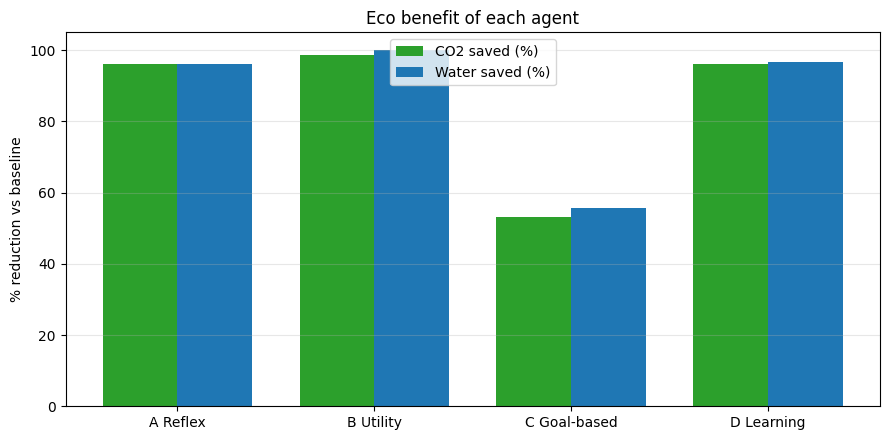

In [20]:
rows = []
for k, name in [("A", "A: Reflex (crowd)"), ("B", "B: Utility (patients)"), ("C", "C: Goal-based (vans)"), ("D", "D: Learning (sports)")]:
    e = ECO[k]
    rows.append([name, e["unit"], round(e["base_co2"], 2), round(e["eco_co2"], 2), f"{1 - e['eco_co2']/e['base_co2']:.0%}",
                 round(e["base_water"], 2), round(e["eco_water"], 2), f"{1 - e['eco_water']/e['base_water']:.0%}"])
summary = pd.DataFrame(rows, columns=["Agent", "Unit", "Baseline CO2 g", "Eco CO2 g", "CO2 saved",
                                      "Baseline water L", "Eco water L", "Water saved"])
print(summary.to_string(index=False))

x = np.arange(4); wd = 0.38
sav_co2   = [100 * (1 - ECO[k]["eco_co2"]   / ECO[k]["base_co2"])   for k in "ABCD"]
sav_water = [100 * (1 - ECO[k]["eco_water"] / ECO[k]["base_water"]) if ECO[k]["base_water"] > 0 else 0 for k in "ABCD"]
plt.figure(figsize=(9, 4.5))
plt.bar(x - wd/2, sav_co2, wd, label="CO2 saved (%)", color="tab:green")
plt.bar(x + wd/2, sav_water, wd, label="Water saved (%)", color="tab:blue")
plt.xticks(x, ["A Reflex", "B Utility", "C Goal-based", "D Learning"]); plt.ylabel("% reduction vs baseline")
plt.title("Eco benefit of each agent"); plt.legend(); plt.grid(axis="y", alpha=.3); plt.ylim(0, 105)
plt.tight_layout(); plt.show()